In [39]:
'''
Essay Evaluator
'''
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import TypedDict
from dotenv import load_dotenv

In [40]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

llm.invoke("hi").content

'Hello! How can I help you today?'

In [41]:
class Evaluator(BaseModel): 
    summary: str = Field(description="Overall summary of the given essay")
    score: float = Field(description="Score of essay between 0-10")

class FinalEvaluator(BaseModel): 
    summary: str = Field(description="Overall summary of the given evaluation")

In [42]:

initial_state = {"essay": """The Importance of Technology in Education
Technology has become an important part of modern education. Students can now access information, attend online classes, watch educational videos, and use various digital tools to improve their learning. Technology also allows teachers to make lessons more interactive through presentations, simulations, and online resources.
One of the biggest advantages of technology in education is easy access to information. Students are no longer limited to textbooks or classroom discussions. They can explore different perspectives and learn at their own pace. Online learning platforms also make education more accessible to people who may not have access to traditional educational institutions.
However, technology also has some disadvantages. Excessive use of digital devices can distract students and reduce their ability to concentrate. Not every student has equal access to computers or reliable internet, which can create differences in learning opportunities. Therefore, technology should be used as a tool to support education rather than completely replace traditional teaching methods.
In conclusion, technology has significantly changed the way students learn and teachers teach. When used properly, it can make education more accessible, engaging, and effective. The key is to maintain a balance between technology-based learning and traditional methods."""}

In [43]:
class State(TypedDict):
    essay: str
    final_summary: str
    final_score: float 
    cot_summary: str
    cot_score: float
    dot_summary: str
    dot_score: float
    lang_summary: str
    lang_score: float

In [44]:
# 1. based on clarity of thought
cot_prompt = ChatPromptTemplate.from_messages([
    ("system", "Evaluate the essay based on clarity of thought. Do not return any other fields."),
    ("human", "Essay: {essay}")
])

#2. based on depth of thought
dot_prompt = ChatPromptTemplate.from_messages([
    ("system", "Evaluate the response based on depth of thought.Do not return any other fields."),
    ("human", "Essay: {essay}")
])

#3. based on language
lang_prompt = ChatPromptTemplate.from_messages([
    ("system", "Evaluate the response based on language quality. Do not return any other fields."),
    ("human", "Essay: {essay}")
])

# Final Summaryabs
final_summary_prompt = ChatPromptTemplate.from_messages([
    ("system", """Evaluate the response using the three evaluation results provided below:
        
        1. Clarity of Thought Evaluation
        2. Depth of Thought Evaluation
        3. Language Evaluation
        
        Consider all three evaluations together and provide an overall assessment of the response.
        
        Return exactly one item:
        - summary: A concise overall summary that combines the key strengths and weaknesses from all three evaluations.
        
        The final score should consider clarity of thought, depth of thought, and language quality equally.
        
        Do not return any other fields.
        
        Clarity Evaluation:
        {clarity_evaluation}
        
        Depth Evaluation:
        {depth_evaluation}
        
        Language Evaluation:
        {language_evaluation}
    """),
])

In [45]:
structured_llm = llm.with_structured_output(Evaluator)

In [62]:
def eval_cot(state: State): 
    essay = state['essay']

    chain = cot_prompt | structured_llm 

    result = chain.invoke({"essay": essay})

    return {"cot_summary": result.summary, "cot_score": result.score}

def eval_dot(state: State): 
    essay = state['essay']

    chain = dot_prompt | structured_llm 

    result = chain.invoke({"essay": essay})

    return {"dot_summary": result.summary, "dot_score": result.score}

def eval_lang(state: State): 
    essay = state['essay']

    chain = lang_prompt | structured_llm 

    result = chain.invoke({"essay": essay})

    return {"lang_summary": result.summary, "lang_score": result.score}

def final_eval(state: State): 
    cot_summary= state['cot_summary']
    lang_summary= state['lang_summary']
    dot_summary= state['dot_summary']
    
    cot_score= state['cot_score']
    dot_score= state['dot_score']
    lang_score= state['lang_score']

    avg_score = (cot_score + dot_score + lang_score) / 3
    
    chain = final_summary_prompt | llm.with_structured_output(FinalEvaluator) 

    result = chain.invoke({"clarity_evaluation":cot_summary, "depth_evaluation": dot_summary, "language_evaluation": lang_summary})
    
    return {"final_summary": result.summary, "final_score": round(avg_score,2)}


In [63]:
# graph intial
graph = StateGraph(State)

# graph node add 
graph.add_node('eval_cot', eval_cot)
graph.add_node('eval_dot', eval_dot)
graph.add_node('eval_lang', eval_lang)
graph.add_node('final_eval', final_eval)

# graph edge add 
graph.add_edge(START, 'eval_cot')
graph.add_edge(START, 'eval_dot')
graph.add_edge(START, 'eval_lang')
graph.add_edge("eval_lang", 'final_eval')
graph.add_edge("eval_dot", 'final_eval')
graph.add_edge("eval_cot", 'final_eval')
graph.add_edge('final_eval', END)

# graph compile
workflow = graph.compile()

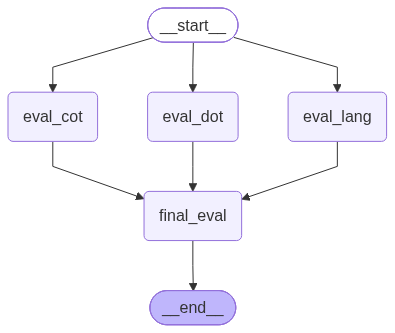

In [64]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [65]:
# Invoke graph

final_state = workflow.invoke(initial_state)
print(final_state["final_summary"])
print(final_state["final_score"])

The response is clear, logically organized, and well‑written, presenting a balanced view of technology in education with appropriate vocabulary and a coherent structure. However, its analysis remains superficial, lacking depth, concrete examples, and nuanced argumentation, and it shows occasional repetition.
7.33
